In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from yfinance import download as yf_download

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
from collections import Counter
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier, plot_importance, plot_tree


In [81]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [44]:
tickers = ['IONQ', 'ABBV', 'AZN', 'MRK', 'NVS']

data = yf_download(tickers, start='2025-01-01', end='2025-12-31', group_by='ticker')

[                       0%                       ]

[*********************100%***********************]  5 of 5 completed


In [45]:
data  = pd.DataFrame(data)

data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')
data['Date'] = data['Date'].apply(lambda x: x.date())

data

Ticker        Date        ABBV                                               \
Price                     Open        High         Low       Close   Volume   
0       2025-01-02  169.837286  170.901972  169.114807  170.578766  4092000   
1       2025-01-03  170.787898  172.603581  169.970367  172.270859  4380200   
2       2025-01-06  171.852605  172.993343  170.407662  171.206192  6302100   
3       2025-01-07  170.759389  173.173951  169.580619  170.664322  5905200   
4       2025-01-08  170.350610  170.388643  167.479742  169.685181  4488500   
..             ...         ...         ...         ...         ...      ...   
244     2025-12-23  224.535676  227.064179  224.230683  225.096466  3612100   
245     2025-12-24  225.755675  227.074039  225.283413  226.178726  1744900   
246     2025-12-26  226.109837  226.887077  224.988226  226.267242  1593900   
247     2025-12-29  226.434510  228.274331  226.031140  227.113373  3803000   
248     2025-12-30  227.044514  227.477413  224.929214  226.031143  2348000   

Ticker       IONQ                                   ...         NVS  \
Price        Open       High        Low      Close  ...        Open   
0       41.279999  43.790001  38.459999  43.099998  ...   91.235507   
1       43.099998  47.909000  43.000000  47.770000  ...   91.123234   
2       48.299999  51.660000  47.133999  51.070000  ...   91.534924   
3       51.279999  54.740002  48.730000  49.590000  ...   92.442506   
4       38.750000  39.000000  25.924000  30.250000  ...   92.779344   
..            ...        ...        ...        ...  ...         ...   
244     52.724998  54.540001  51.150002  51.389999  ...  135.476535   
245     51.700001  51.880001  48.730000  49.820000  ...  134.952478   
246     49.590000  49.680000  45.759998  46.000000  ...  134.777797   
247     45.459999  46.759998  44.660000  45.250000  ...  134.758395   
248     46.410000  46.830002  45.095001  45.310001  ...  134.661340   

Ticker                                                      AZN              \
Price         High         Low       Close   Volume        Open        High   
0        91.693975   90.674117   90.889313  1084900  127.928198  128.703406   
1        91.600419   90.926748   91.357147  1401900  128.780907  128.819676   
2        92.124382   91.207447   91.413284  1377300  129.478590  130.951483   
3        93.172314   92.367652   92.610924  1363500  129.459228  130.486373   
4        94.192174   92.189878   93.771133  1818300  128.315782  129.342926   
..             ...         ...         ...      ...         ...         ...   
244     136.039390  134.680749  135.020416  1945400  183.130800  184.278835   
245     135.360070  134.438134  134.777802   647000  182.734937  183.308954   
246     135.107751  134.302265  135.068924   587100  183.150595  183.902763   
247     135.330964  134.738981  135.088348   777400  182.754729  183.863169   
248     135.010707  134.321687  134.622528   710400  183.407931  183.843378   

Ticker                                   
Price          Low       Close   Volume  
0       127.618109  127.676247  1399050  
1       128.141374  128.393311  1932000  
2       128.645244  129.536728  2699950  
3       129.091001  129.149139  2055550  
4       127.288638  129.032852  1989100  
..             ...         ...      ...  
244     181.982780  182.378647  1772200  
245     182.121338  182.992249   592350  
246     182.457820  183.882965   834700  
247     182.754729  183.130798  1185900  
248     182.814115  183.111023   865100  

[249 rows x 26 columns]

In [82]:
def filter_stock_data(df, sym):
    filtered = df.filter(regex=sym)
    filtered = pd.DataFrame(filtered)
    return filtered

In [83]:
# Call the function to filter the data for IONQ
filter_stock_data(data, 'IONQ')

Ticker       IONQ                                            
Price        Open       High        Low      Close     Volume
0       41.279999  43.790001  38.459999  43.099998   22986200
1       43.099998  47.909000  43.000000  47.770000   28235500
2       48.299999  51.660000  47.133999  51.070000   23299900
3       51.279999  54.740002  48.730000  49.590000   27090300
4       38.750000  39.000000  25.924000  30.250000  128343800
..            ...        ...        ...        ...        ...
244     52.724998  54.540001  51.150002  51.389999   15263300
245     51.700001  51.880001  48.730000  49.820000   10354100
246     49.590000  49.680000  45.759998  46.000000   19679600
247     45.459999  46.759998  44.660000  45.250000   17259800
248     46.410000  46.830002  45.095001  45.310001   13552200

[249 rows x 5 columns]

In [85]:
ticker = 'IONQ'

def create_backtest_df(ticker, data):
    # Date source: prefer 'Date' column, otherwise use index
    if 'Date' in data.columns:
        dates = pd.to_datetime(data['Date'])
    elif isinstance(data.index, pd.DatetimeIndex):
        dates = data.index
    else:
        dates = pd.to_datetime(data.index)

    def get_col(field):
        # MultiIndex columns (ticker, field)
        if isinstance(data.columns, pd.MultiIndex):
            key = (ticker, field)
            if key in data.columns:
                return data[key].reset_index(drop=True)
            # fallback: find matching first-level ticker + case-insensitive second-level match
            for c in data.columns:
                try:
                    if c[0] == ticker and str(c[1]).lower() == field.lower():
                        return data[c].reset_index(drop=True)
                except Exception:
                    continue
        else:
            # common flat-name variants
            for candidate in (f"{ticker} {field}", f"{ticker}_{field}", f"{ticker}.{field}", field):
                if candidate in data.columns:
                    return data[candidate].reset_index(drop=True)
        raise KeyError(f"Column for {ticker} {field} not found")

    df_backtest = pd.DataFrame({
        'Date': dates.reset_index(drop=True),
        'Open': get_col('Open'),
        'High': get_col('High'),
        'Low': get_col('Low'),
        'Close': get_col('Close'),
        'Volume': get_col('Volume'),
    }).reset_index(drop=True)

    df_backtest.index = pd.to_datetime(df_backtest['Date'])
    return df_backtest

In [57]:
# Create backtest DataFrame for the specified ticker
df_backtest = create_backtest_df('IONQ', data)

df_backtest.drop(columns=['Date'], inplace=True)

df_backtest

,Open,High,Low,Close,Volume
Date,,,,,
2025-01-02,41.279999,43.790001,38.459999,43.099998,22986200
2025-01-03,43.099998,47.909000,43.000000,47.770000,28235500
2025-01-06,48.299999,51.660000,47.133999,51.070000,23299900
2025-01-07,51.279999,54.740002,48.730000,49.590000,27090300
2025-01-08,38.750000,39.000000,25.924000,30.250000,128343800
...,...,...,...,...,...
2025-12-23,52.724998,54.540001,51.150002,51.389999,15263300
2025-12-24,51.700001,51.880001,48.730000,49.820000,10354100
2025-12-26,49.590000,49.680000,45.759998,46.000000,19679600


In [59]:
from backtesting import Backtest, Strategy
from backtesting.lib import crossover
import talib

In [87]:
class SmaCross(Strategy):
# Class-level parameters — override via Backtest.run(n1=...) or optimize()
    n1 = 10
    n2 = 20
    n3 = 50
            
    def init(self):
        # Precompute moving averages
        self.sma1 = self.I(lambda x: talib.SMA(x, self.n1), self.data.Close)
        self.sma2 = self.I(lambda x: talib.SMA(x, self.n2), self.data.Close)
        self.sma3 = self.I(lambda x: talib.SMA(x, self.n3), self.data.Close)

    def next(self):
        # Called for each new bar
        if crossover(self.sma1, self.sma2): # type: ignore[arg-type]
            self.buy()
        elif crossover(self.sma2, self.sma1): # type: ignore[arg-type]
            self.position.close()

In [96]:
bt = Backtest(df_backtest, SmaCross, cash=10000, commission=0.002)
stats = bt.run()

print(stats)

Backtest.run:   0%|          | 0/199 [00:00<?, ?bar/s]

Start                     2025-01-02 00:00:00
End                       2025-12-30 00:00:00
Duration                    362 days 00:00:00
Exposure Time [%]                    48.59438
Equity Final [$]                  16174.70462
Equity Peak [$]                   22747.69442
Commissions [$]                     297.99622
Return [%]                           61.74705
Buy & Hold Return [%]                 81.7489
Return (Ann.) [%]                    62.68685
Volatility (Ann.) [%]               135.39591
CAGR [%]                             39.75836
Sharpe Ratio                          0.46299
Sortino Ratio                         1.58141
Calmar Ratio                          1.70334
Alpha [%]                            31.78156
Beta                                  0.36656
Max. Drawdown [%]                   -36.80231
Avg. Drawdown [%]                   -13.82481
Max. Drawdown Duration      108 days 00:00:00
Avg. Drawdown Duration       30 days 00:00:00
# Trades                          

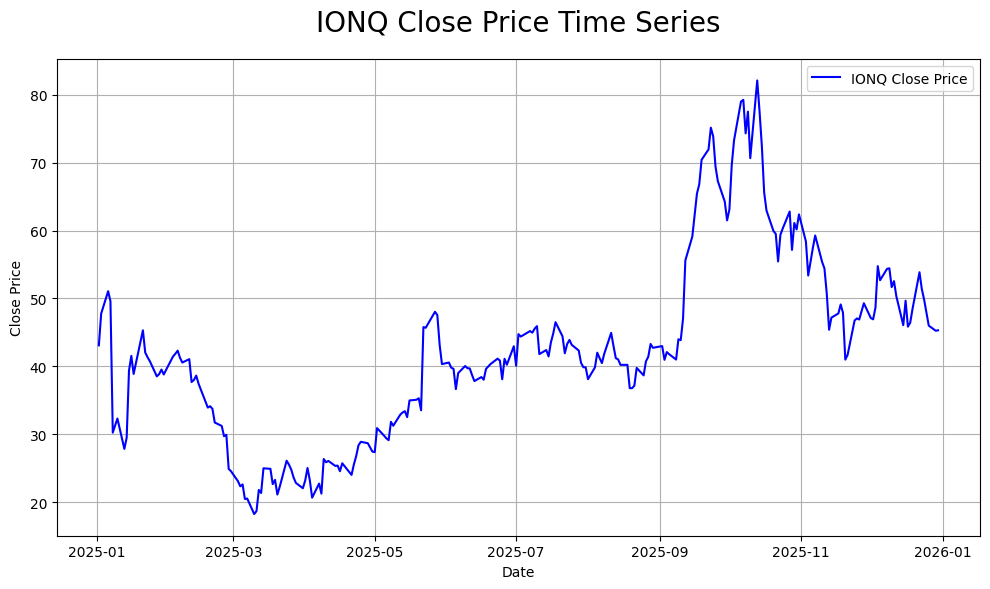

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_backtest.index, df_backtest[('Close')], label='IONQ Close Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('IONQ Close Price Time Series', fontsize=20, pad=20)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()